In [1]:
import numpy as np
import matplotlib.pyplot as plt

## **class LinearRegression:**

Kendi lineer regresyon model sınıfın. İçinde iki ana fonksiyon var:

- fit() → modeli **eğitir** (β katsayılarını bulur)
- predict() → yeni veride **tahmin** yapar

- self.beta_hats: **β̂ (beta)** → öğrenilen katsayılar (intercept dahil olabilir)
- self.L: eğitim kaybı (**loss**) → kare hata toplamı
- self.y_hat: eğitim verisinde modelin ürettiği tahminler
- self._fit_added_intercept: eğitimde X’in başına **1’ler sütunu ekledik mi?**

    Bunu predict’te test verisine de aynı işlemi uygulamak için tutuyoruz.

In [2]:
# 1 - Implementing Ordinary Linear Regression from Scratch

class LinearRegression:

    def __init__(self):
        self.beta_hats = None # Modelin öğrendiği katsayılar (coefficients) ve intercept (bias) değerleri
        self.L = None # Eğitim kaybı (Loss) değeri
        self.y_hat = None # Modelin tahmin ettiği değerler (predictions)
        self._fit_added_intercept = False # Modelin eğitim sırasında intercept (bias) ekleyip eklemediğini takip eder

    def fit(self, X, y, intercept = False): # Eğitim (fit) fonksiyonu

        if intercept == False: # Eğer X'te intercept yoksa ben ekleyeceğim. Intercept sabit terimdir. Beta0 olarak adlandırılır.
            ones = np.ones(len(X)).reshape(len(X), 1) # X'in uzunluğu kadar 1'lerden oluşan bir sütun vektörü oluşturulur
            X = np.concatenate((ones, X), axis = 1) # X'in soluna intercept sütunu eklenir (1'lerden oluşan sütun)
            self._fit_added_intercept = True # Intercept eklenmiş olduğunu belirtir
        else: # Eğer X'te intercept zaten varsa, ekleme yapmaz ve fit_added_intercept'ı False olarak bırakır
            self._fit_added_intercept = False

        self.X = np.array(X) # X eğitim tasarım matrisi
        self.y = np.array(y) # hedef vektörü
        self.N, self.D = self.X.shape # N: örnek sayısı, D: özellik sayısı (intercept dahil olabilir)

        # 2 - Normal denklemi kullanarak beta katsayılarını hesaplamak
        XtX = np.dot(self.X.T, self.X) # X'in transpozu ile X'in çarpımı (XᵀX)
        XtX_inverse = np.linalg.inv(XtX) # (XᵀX)'in tersi
        Xty = np.dot(self.X.T, self.y) # X'in transpozu ile y'nin çarpımı (Xᵀy)
        self.beta_hats = np.dot(XtX_inverse, Xty) # Normal denklemi: β̂ = (XᵀX)⁻¹ Xᵀy

        # 3 - Eğitim setinde tahmin üretme
        self.y_hat = np.dot(self.X, self.beta_hats)

        # 4 - Eğitim kaybını hesaplama (kare hata toplamı)
        self.L = .5 * np.sum((self.y - self.y_hat) ** 2) # L = 0.5 * Σ(y_i - ŷ_i)²
        # Gerçek ile tahmin farklarının karelerini topluyor. 0.5 ile çarpanı türev için

    def predict(self, X_test, intercept = True): # Model eğitildikten sonra yeni veri için tahmin.

        X_test = np.array(X_test) # Test verisini numpy array'e çevirir

        if (self._fit_added_intercept == True) and (intercept == False): # Eğer başlangıçta intercept yoksa ve biz eğitim sırasında intercept eklediysek. Test verisine de eklememiz gerekiyor.
            ones = np.ones(len(X_test)).reshape(len(X_test), 1) # Test verisi için de 1'lerden oluşan bir sütun vektörü oluşturulur
            X_test = np.concatenate((ones, X_test), axis = 1) # Test verisinin soluna intercept sütunu eklenir

        # 5 - Test verisi için tahminler üretme
        self.y_test_hat = np.dot(X_test, self.beta_hats) # Test verisi için tahminler: ŷ_test = X_test * β̂
        return self.y_test_hat


1:  $y = \beta_0 + \beta_1 x$

2: $\hat{\beta} = (X^\top X)^{-1} X^\top y$

3: $\hat{y} = X\hat{\beta}$

4: L = $\frac{1}{2}\sum_{n=1}^{N}(y_n - \hat{y}_n)^2$

5: $\hat{y}_{test} = X_{test}\hat{\beta}$

- **X.T**: *Transpose of X* → **X’in transpozu**
- **XtX**: *X-transpose times X* → **XᵀX**
- **XtX_inverse**: *Inverse of (XᵀX)* → **(XᵀX)’in tersi**
- **Xty**: *X-transpose times y* → **Xᵀy**

In [3]:
# Aşağıdaki kod, basit bir veri üretir (y = 3 + 2x + gürültü), modeli eğitir, katsayıları ve loss’u yazdırır, sonra test tahmini yapar:

np.random.seed(42)

N = 50
X = (np.random.rand(N, 1) * 10) # shape (N,1)
noise = np.random.randn(N) * 1.0
y = 3 + 2 * X.flatten() + noise # y = 3 + 2x + noise

model = LinearRegression()
model.fit(X, y, intercept=False)

y_hat = model.y_hat # eğitim verisi için modelin tahminleri

# R^2 score
ss_res = np.sum((y - y_hat) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

print("beta_hats:", model.beta_hats)
print("loss L:", model.L)
print("R2:", r2)


beta_hats: [3.09668927 1.9776566 ]
loss L: 20.576778593717183
R2: 0.9749140085676858


Bu, modelin öğrendiği katsayılar (**β̂**) demek:

$\hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x$

- **β̂0 = 3.0967** → **intercept (sabit terim)**

    x = 0 iken y’nin tahmini yaklaşık 3.10

- **β̂1 = 1.9777** → **eğim (slope)**

    x 1 artarsa, y tahmini ortalama **~1.98** artar.


Sen veriyi üretirken aslında şunu yapmıştın:

$y = 3 + 2x + \text{noise}$

Modelin bulduğu değerler **3’e çok yakın** ve **2’ye çok yakın** → yani model doğru ilişkiyi yakalamış.

##

L = $\frac{1}{2}\sum_{n=1}^{N}(y_n-\hat{y}_n)^2$

Bu şu anlama gelir:

- **Eğitim verisindeki tüm hataların (residual)** karelerini topluyor,
- sonra **0.5 ile çarpıyor**.

Bu yüzden:

- L **ne kadar küçükse**, model eğitim verisine o kadar iyi uymuş demektir.
- Ama L’nin “iyi mi kötü mü” olması **verinin ölçeğine, N’e ve gürültüye** bağlıdır. Tek başına evrensel bir anlamı yok.

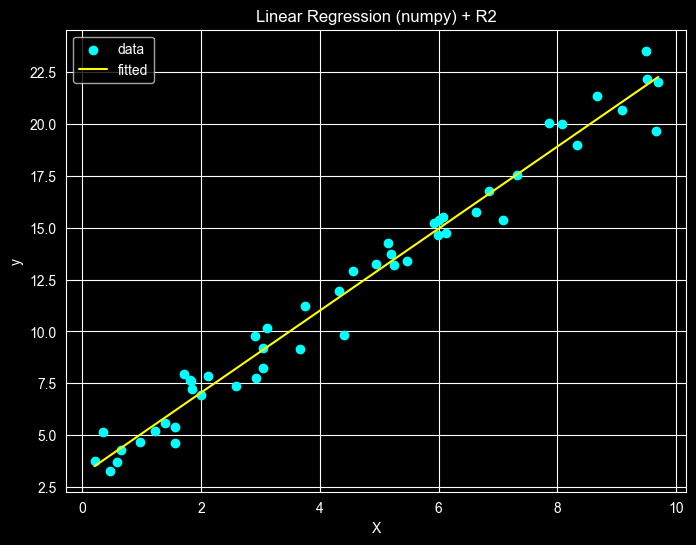

In [10]:
# Plot
x_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_line = model.predict(x_line, intercept=False)

plt.figure(figsize=(8, 6), dpi=100)
plt.scatter(X, y, label="data", color='cyan')
plt.plot(x_line, y_line, label="fitted", color='yellow')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression (numpy) + R2")
plt.legend()
plt.show()

In [5]:
;

''